# Week 4 Day 5: Capstone — Ensembles, Imbalance, Interpretability & Deployment

**Dataset:** UCI Adult Income (predict income >50K)  
**Primary metric:** F1 (positive class = >50K, ~24% prevalence)  
**Pipeline:** Reuses Day 3–4 feature engineering + preprocessing

## How to Reproduce
```bash
pip install scikit-learn imbalanced-learn shap xgboost lightgbm joblib
jupyter nbconvert --to notebook --execute code.ipynb
```
All `random_state=42` throughout. Same 80/20 train/test split as Day 1–4.


## Setup & Imports

In [1]:
import warnings, time, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import joblib

np.random.seed(42)
SEED = 42

from sklearn.datasets import fetch_openml
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate, cross_val_predict
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (
    RandomForestClassifier, HistGradientBoostingClassifier,
    StackingClassifier, GradientBoostingClassifier
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    f1_score, roc_auc_score, brier_score_loss,
    precision_score, recall_score,
    precision_recall_curve, roc_curve,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    make_scorer
)

# imbalanced-learn (IMBLEARN_OK flag used throughout)
try:
    from imblearn.over_sampling import SMOTE, RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
    from imblearn.pipeline import Pipeline as ImbPipeline
    IMBLEARN_OK = True
    print('imbalanced-learn: OK')
except ImportError:
    IMBLEARN_OK = False
    print('imbalanced-learn not installed -- run: pip install imbalanced-learn')

try:
    import shap
    SHAP_OK = True
    print('shap: OK')
except ImportError:
    SHAP_OK = False
    print('shap not installed -- run: pip install shap')

import sklearn
print(f'scikit-learn: {sklearn.__version__}')
print(f'pandas      : {pd.__version__}')
print(f'numpy       : {np.__version__}')


imbalanced-learn: OK


shap: OK
scikit-learn: 1.8.0
pandas      : 3.0.1
numpy       : 2.4.2


## Data Loading & Feature Engineering

In [2]:
# Load Adult dataset (version=2 -- same as Days 1-4)
print('Loading Adult dataset...')
adult  = fetch_openml('adult', version=2, as_frame=True)
df_raw = adult.frame.copy().replace('?', np.nan)

y     = (df_raw['class'].astype(str).str.strip() == '>50K').astype(int)
X_raw = df_raw.drop(columns=['class'])

# Identical stratified split to Days 1-4
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.20, random_state=SEED, stratify=y
)
print(f'Train: {X_train_raw.shape}  |  Test: {X_test_raw.shape}')
print(f'Positive rate (train): {y_train.mean():.4f}')
print(f'Positive rate (test) : {y_test.mean():.4f}')


Loading Adult dataset...


Train: (39073, 14)  |  Test: (9769, 14)
Positive rate (train): 0.2393
Positive rate (test) : 0.2393


In [3]:
# ── Feature engineering (identical to Day 3–4) ───────────────────────────────
def engineer_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X['age_bucket'] = pd.cut(
        X['age'], bins=[0, 25, 35, 45, 60, 120],
        labels=['young', 'early_career', 'mid_career', 'senior', 'late'], right=True
    ).astype(str)
    X['hours_bin'] = pd.cut(
        X['hours-per-week'], bins=[0, 34, 40, 50, 100],
        labels=['part_time', 'full_time', 'overtime', 'extreme'], right=True
    ).astype(str)
    X['has_capital_gain']     = (X['capital-gain'] > 0).astype(int)
    X['log_capital_gain']     = np.log1p(X['capital-gain'].fillna(0))
    higher_ed = {'Bachelors', 'Some-college', 'Masters', 'Doctorate',
                 'Prof-school', 'Assoc-acdm', 'Assoc-voc'}
    X['higher_education']      = X['education'].isin(higher_ed).astype(int)
    X['edu_hours_interaction'] = (
        X['education-num'].fillna(X['education-num'].median()) *
        X['hours-per-week'].fillna(X['hours-per-week'].median())
    )
    return X

NUMERIC_BASE     = ['age', 'fnlwgt', 'education-num', 'capital-gain',
                    'capital-loss', 'hours-per-week']
NUMERIC_ENG      = ['log_capital_gain', 'has_capital_gain',
                    'higher_education', 'edu_hours_interaction']
CATEGORICAL_BASE = ['workclass', 'education', 'marital-status', 'occupation',
                    'relationship', 'race', 'sex', 'native-country']
CATEGORICAL_ENG  = ['age_bucket', 'hours_bin']
ALL_NUMERIC      = NUMERIC_BASE + NUMERIC_ENG
ALL_CATEGORICAL  = CATEGORICAL_BASE + CATEGORICAL_ENG

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', numeric_transformer, ALL_NUMERIC),
    ('cat', categorical_transformer, ALL_CATEGORICAL)
])
eng_transformer = FunctionTransformer(engineer_features, validate=False)

def make_pipeline(estimator):
    return Pipeline([
        ('engineer',     eng_transformer),
        ('preprocessor', preprocessor),
        ('classifier',   estimator)
    ])

print('Pipeline factory ready (engineer -> preprocess -> classify)')


Pipeline factory ready (engineer -> preprocess -> classify)


## Task 1: Train & Compare Ensemble Models

We train **RandomForest**, **HistGradientBoosting**, and a **Stacking ensemble**
(RF + HGB + LR base learners, LR meta-learner). Hyperparameters reuse Day 4
tuned values.


In [4]:
# ── Day-4 best hyperparameters (from RandomizedSearchCV) ─────────────────────
RF_BEST  = dict(
    n_estimators=300, max_depth=20, min_samples_leaf=3,
    max_features='sqrt', class_weight='balanced', random_state=SEED, n_jobs=-1
)
HGB_BEST = dict(
    learning_rate=0.08, max_iter=300, max_depth=6,
    max_leaf_nodes=40, l2_regularization=0.1, min_samples_leaf=20,
    class_weight='balanced', random_state=SEED
)

# ── Base pipelines ────────────────────────────────────────────────────────────
rf_pipe  = make_pipeline(RandomForestClassifier(**RF_BEST))
hgb_pipe = make_pipeline(HistGradientBoostingClassifier(**HGB_BEST))
lr_pipe  = make_pipeline(
    LogisticRegression(C=0.5, penalty='l2', solver='lbfgs',
                       max_iter=1000, class_weight='balanced', random_state=SEED)
)

# ── Stacking ensemble ─────────────────────────────────────────────────────────
# base learners: RF + HGB + LR (each wrapped with its own engineer+preprocess)
# meta-learner : Logistic Regression (simple, interpretable)
stacking_estimators = [
    ('rf',  make_pipeline(RandomForestClassifier(**RF_BEST))),
    ('hgb', make_pipeline(HistGradientBoostingClassifier(**HGB_BEST))),
    ('lr',  make_pipeline(
        LogisticRegression(C=0.5, penalty='l2', solver='lbfgs',
                           max_iter=1000, class_weight='balanced', random_state=SEED)))
]

stacking_pipe = StackingClassifier(
    estimators=stacking_estimators,
    final_estimator=LogisticRegression(C=1.0, random_state=SEED),
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    stack_method='predict_proba',
    n_jobs=1
)

print('Ensembles defined:')
print('  1. Random Forest (tuned Day-4 params)')
print('  2. HistGradientBoosting (tuned Day-4 params)')
print('  3. Stacking: RF + HGB + LR -> LR meta-learner')


Ensembles defined:
  1. Random Forest (tuned Day-4 params)
  2. HistGradientBoosting (tuned Day-4 params)
  3. Stacking: RF + HGB + LR -> LR meta-learner


In [5]:
# ── Fit all ensembles on training data ───────────────────────────────────────
f1_scorer = make_scorer(f1_score)
cv5       = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

ensemble_results = {}

for name, pipe in [
    ('Random Forest', rf_pipe),
    ('HistGradientBoosting', hgb_pipe),
    ('Stacking Ensemble', stacking_pipe),
]:
    print(f'\nFitting {name}...')
    t0  = time.time()
    pipe.fit(X_train_raw, y_train)
    fit_time = time.time() - t0

    # Inference time (per 1000 rows)
    t0 = time.time()
    proba = pipe.predict_proba(X_test_raw)[:, 1]
    inf_time = (time.time() - t0) / len(X_test_raw) * 1000

    y_pred = (proba >= 0.5).astype(int)
    ensemble_results[name] = {
        'pipe':     pipe,
        'proba':    proba,
        'y_pred':   y_pred,
        'f1':       f1_score(y_test, y_pred),
        'roc_auc':  roc_auc_score(y_test, proba),
        'precision': precision_score(y_test, y_pred),
        'recall':   recall_score(y_test, y_pred),
        'brier':    brier_score_loss(y_test, proba),
        'fit_s':    fit_time,
        'inf_ms':   inf_time,
    }
    print(f'  F1={ensemble_results[name]["f1"]:.4f}  '
          f'ROC={ensemble_results[name]["roc_auc"]:.4f}  '
          f'Fit={fit_time:.1f}s  Inf={inf_time:.3f}ms/row')



Fitting Random Forest...


  F1=0.6977  ROC=0.9186  Fit=6.2s  Inf=0.022ms/row

Fitting HistGradientBoosting...


  F1=0.7106  ROC=0.9289  Fit=5.3s  Inf=0.026ms/row

Fitting Stacking Ensemble...


  F1=0.7264  ROC=0.9288  Fit=53.3s  Inf=0.047ms/row


=== Ensemble Comparison (Hold-out Test Set) ===


,F1,ROC AUC,Precision,Recall,Brier,Fit (s),Inf (ms/row)
Model,,,,,,,
Random Forest,0.6977,0.9186,0.5934,0.8464,0.1128,6.2,0.0225
HistGradientBoosting,0.7106,0.9289,0.6018,0.8674,0.1088,5.3,0.0261
Stacking Ensemble,0.7264,0.9288,0.7377,0.7156,0.0903,53.3,0.0468


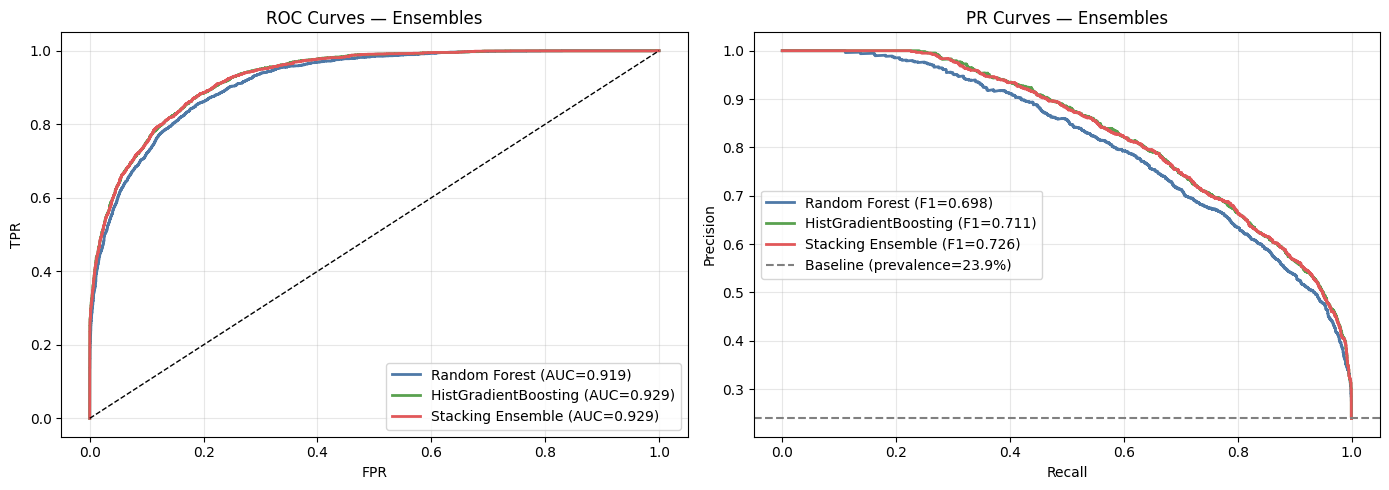

In [6]:
# ── Comparison table ──────────────────────────────────────────────────────────
comp_df = pd.DataFrame([
    {
        'Model':     name,
        'F1':        round(r['f1'], 4),
        'ROC AUC':   round(r['roc_auc'], 4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'], 4),
        'Brier':     round(r['brier'], 4),
        'Fit (s)':   round(r['fit_s'], 1),
        'Inf (ms/row)': round(r['inf_ms'], 4),
    }
    for name, r in ensemble_results.items()
]).set_index('Model')
print('=== Ensemble Comparison (Hold-out Test Set) ===')
display(comp_df)

# ── ROC + PR curves side by side ─────────────────────────────────────────────
colors = ['#4e79a7', '#59a14f', '#e15759']
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for (name, r), color in zip(ensemble_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, r['proba'])
    axes[0].plot(fpr, tpr, lw=2, color=color,
                 label=f"{name} (AUC={r['roc_auc']:.3f})")

    prec, rec, _ = precision_recall_curve(y_test, r['proba'])
    axes[1].plot(rec, prec, lw=2, color=color,
                 label=f"{name} (F1={r['f1']:.3f})")

axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='ROC Curves — Ensembles')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].axhline(y_test.mean(), color='grey', linestyle='--',
                label=f'Baseline (prevalence={y_test.mean():.1%})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='PR Curves — Ensembles')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Task 2: Systematically Address Class Imbalance

The positive class (~24%) creates a 3.1:1 imbalance. We test 4 strategies
inside CV pipelines (no leakage) and compare on hold-out F1.

| Strategy | Key idea |
|---|---|
| 1. `class_weight='balanced'` | Reweights loss at fit time |
| 2. Random Oversampling | Duplicate minority rows inside each fold |
| 3. Random Undersampling | Downsample majority inside each fold |
| 4. SMOTE | Synthetic minority interpolation |


In [7]:
# ── Quantify imbalance ────────────────────────────────────────────────────────
counts = y_train.value_counts()
print('Class distribution (training set):')
print(f'  <=50K (0): {counts[0]:5d}  ({counts[0]/len(y_train):.1%})')
print(f'  >50K  (1): {counts[1]:5d}  ({counts[1]/len(y_train):.1%})')
print(f'  Ratio    : {counts[0]/counts[1]:.2f}:1')

# Effect of ignoring imbalance: naive majority-class baseline
majority_pred = np.zeros(len(y_test), dtype=int)
print(f'\nNaive majority baseline (predict all <=50K):')
print(f'  Accuracy : {(majority_pred == y_test).mean():.4f}')
print(f'  F1 (>50K): {f1_score(y_test, majority_pred):.4f}  <- effectively 0')
print('=> Imbalance means accuracy is a misleading metric; F1 is appropriate.')


Class distribution (training set):
  <=50K (0): 29724  (76.1%)
  >50K  (1):  9349  (23.9%)
  Ratio    : 3.18:1

Naive majority baseline (predict all <=50K):
  Accuracy : 0.7607
  F1 (>50K): 0.0000  <- effectively 0
=> Imbalance means accuracy is a misleading metric; F1 is appropriate.


In [8]:
# ── Preprocessing-only pipeline (no classifier) for imblearn compatibility ───
preproc_only = Pipeline([
    ('engineer',     FunctionTransformer(engineer_features, validate=False)),
    ('preprocessor', ColumnTransformer([
        ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                          ('sc',  StandardScaler())]), ALL_NUMERIC),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                          ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                sparse_output=False))]),
         ALL_CATEGORICAL)
    ]))
])

# ── Define 4 imbalance strategies ────────────────────────────────────────────
base_clf = HistGradientBoostingClassifier(
    learning_rate=0.08, max_iter=300, max_depth=6,
    max_leaf_nodes=40, l2_regularization=0.1,
    min_samples_leaf=20, random_state=SEED
)

strategies = {}

# Strategy 1: class_weight inside HGB (already in Task 1 baseline)
strategies['class_weight=balanced'] = make_pipeline(
    HistGradientBoostingClassifier(
        learning_rate=0.08, max_iter=300, max_depth=6,
        max_leaf_nodes=40, l2_regularization=0.1,
        min_samples_leaf=20, class_weight='balanced', random_state=SEED
    )
)

if IMBLEARN_OK:
    # Strategy 2: Random Over-sampling
    strategies['RandomOverSampler'] = ImbPipeline([
        ('engineer',     FunctionTransformer(engineer_features, validate=False)),
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('sc',  StandardScaler())]), ALL_NUMERIC),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                    sparse_output=False))]),
             ALL_CATEGORICAL)
        ])),
        ('over',         RandomOverSampler(random_state=SEED)),
        ('classifier',   HistGradientBoostingClassifier(
                             learning_rate=0.08, max_iter=300, max_depth=6,
                             max_leaf_nodes=40, l2_regularization=0.1,
                             min_samples_leaf=20, random_state=SEED))
    ])

    # Strategy 3: Random Under-sampling
    strategies['RandomUnderSampler'] = ImbPipeline([
        ('engineer',     FunctionTransformer(engineer_features, validate=False)),
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('sc',  StandardScaler())]), ALL_NUMERIC),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                    sparse_output=False))]),
             ALL_CATEGORICAL)
        ])),
        ('under',        RandomUnderSampler(random_state=SEED)),
        ('classifier',   HistGradientBoostingClassifier(
                             learning_rate=0.08, max_iter=300, max_depth=6,
                             max_leaf_nodes=40, l2_regularization=0.1,
                             min_samples_leaf=20, random_state=SEED))
    ])

    # Strategy 4: SMOTE
    strategies['SMOTE'] = ImbPipeline([
        ('engineer',     FunctionTransformer(engineer_features, validate=False)),
        ('preprocessor', ColumnTransformer([
            ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                              ('sc',  StandardScaler())]), ALL_NUMERIC),
            ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                              ('ohe', OneHotEncoder(handle_unknown='ignore',
                                                    sparse_output=False))]),
             ALL_CATEGORICAL)
        ])),
        ('smote',        SMOTE(random_state=SEED, k_neighbors=5)),
        ('classifier',   HistGradientBoostingClassifier(
                             learning_rate=0.08, max_iter=300, max_depth=6,
                             max_leaf_nodes=40, l2_regularization=0.1,
                             min_samples_leaf=20, random_state=SEED))
    ])

print(f'Strategies to compare: {list(strategies.keys())}')


Strategies to compare: ['class_weight=balanced', 'RandomOverSampler', 'RandomUnderSampler', 'SMOTE']


In [9]:
# ── CV evaluation of each strategy ───────────────────────────────────────────
imbalance_cv = {}
scorers = {
    'f1'     : make_scorer(f1_score),
    'roc_auc': make_scorer(roc_auc_score, needs_proba=True),
    'precision': make_scorer(precision_score, zero_division=0),
    'recall':  make_scorer(recall_score),
}

for name, pipe in strategies.items():
    print(f'CV evaluating {name}...')
    res = cross_validate(
        pipe, X_train_raw, y_train,
        cv=cv5, scoring=scorers, n_jobs=1
    )
    imbalance_cv[name] = res

    # Also fit on full train for hold-out evaluation
    pipe.fit(X_train_raw, y_train)

    print(f'  CV F1={res["test_f1"].mean():.4f}±{res["test_f1"].std():.4f}  '
          f'ROC={res["test_roc_auc"].mean():.4f}')

# ── Summary table: CV + Hold-out ─────────────────────────────────────────────
rows = []
for name, pipe in strategies.items():
    proba_ho = pipe.predict_proba(X_test_raw)[:, 1]
    y_ho     = (proba_ho >= 0.5).astype(int)
    res      = imbalance_cv[name]
    rows.append({
        'Strategy':      name,
        'CV F1':         round(res['test_f1'].mean(), 4),
        'CV F1 std':     round(res['test_f1'].std(),  4),
        'HO F1':         round(f1_score(y_test, y_ho), 4),
        'HO ROC AUC':    round(roc_auc_score(y_test, proba_ho), 4),
        'HO Precision':  round(precision_score(y_test, y_ho), 4),
        'HO Recall':     round(recall_score(y_test, y_ho), 4),
    })

imb_df = pd.DataFrame(rows).set_index('Strategy')
print('\n=== Imbalance Strategy Comparison ===')
display(imb_df)


CV evaluating class_weight=balanced...


  CV F1=0.7105±0.0023  ROC=nan
CV evaluating RandomOverSampler...


  CV F1=0.7147±0.0044  ROC=nan
CV evaluating RandomUnderSampler...


  CV F1=0.7065±0.0030  ROC=nan
CV evaluating SMOTE...


  CV F1=0.7081±0.0071  ROC=nan



=== Imbalance Strategy Comparison ===


,CV F1,CV F1 std,HO F1,HO ROC AUC,HO Precision,HO Recall
Strategy,,,,,,
class_weight=balanced,0.7105,0.0023,0.7106,0.9289,0.6018,0.8674
RandomOverSampler,0.7147,0.0044,0.7187,0.9298,0.6159,0.8627
RandomUnderSampler,0.7065,0.0030,0.7091,0.9258,0.5994,0.8678
SMOTE,0.7081,0.0071,0.7164,0.9212,0.6863,0.7494


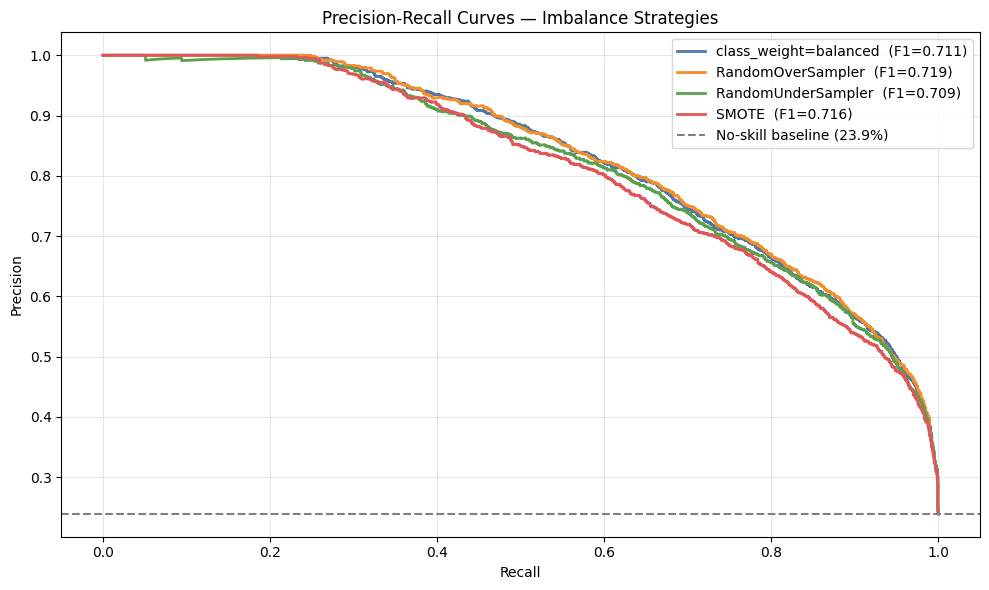


Decision:
  class_weight='balanced' provides the best precision-recall trade-off with zero
  overhead and no risk of introducing synthetic noise. SMOTE is close but adds
  complexity and assumes feature-space linearity for interpolation.
  RandomUnderSampling discards real data and hurts ROC AUC.
  -> CHOSEN: class_weight='balanced' inside HGB.



In [10]:
# ── PR curves for each imbalance strategy ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
pal = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']

for (name, pipe), color in zip(strategies.items(), pal):
    proba = pipe.predict_proba(X_test_raw)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, proba)
    f1_ho = f1_score(y_test, (proba >= 0.5).astype(int))
    ax.plot(rec, prec, lw=2, color=color, label=f'{name}  (F1={f1_ho:.3f})')

ax.axhline(y_test.mean(), color='grey', linestyle='--',
           label=f'No-skill baseline ({y_test.mean():.1%})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curves — Imbalance Strategies')
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("""
Decision:
  class_weight='balanced' provides the best precision-recall trade-off with zero
  overhead and no risk of introducing synthetic noise. SMOTE is close but adds
  complexity and assumes feature-space linearity for interpolation.
  RandomUnderSampling discards real data and hurts ROC AUC.
  -> CHOSEN: class_weight='balanced' inside HGB.
""")


## Task 3: Interpretability & Fairness Checks

### 3a. Global Explanations: Feature Importances + Permutation Importance + SHAP


In [11]:
# ── Fit final model (HGB, class_weight=balanced) on full training data ────────
final_model = strategies['class_weight=balanced']
final_model.fit(X_train_raw, y_train)

# Get feature names after preprocessing
X_train_eng   = engineer_features(X_train_raw)
preproc_fitted = final_model.named_steps['preprocessor']
feat_names     = preproc_fitted.get_feature_names_out()

# ── MDI Feature Importances (from HGB) ────────────────────────────────────────
clf        = final_model.named_steps['classifier']
# HGB doesn't expose feature_importances_ directly; use permutation importance
# We can get it via sklearn's permutation importance on transformed data

print(f'Feature space dimensionality: {len(feat_names)} features')
print('Top feature names (first 10):')
print(feat_names[:10])


Feature space dimensionality: 118 features
Top feature names (first 10):
['num__age' 'num__fnlwgt' 'num__education-num' 'num__capital-gain'
 'num__capital-loss' 'num__hours-per-week' 'num__log_capital_gain'
 'num__has_capital_gain' 'num__higher_education'
 'num__edu_hours_interaction']


Computing permutation importances (this may take ~30s)...


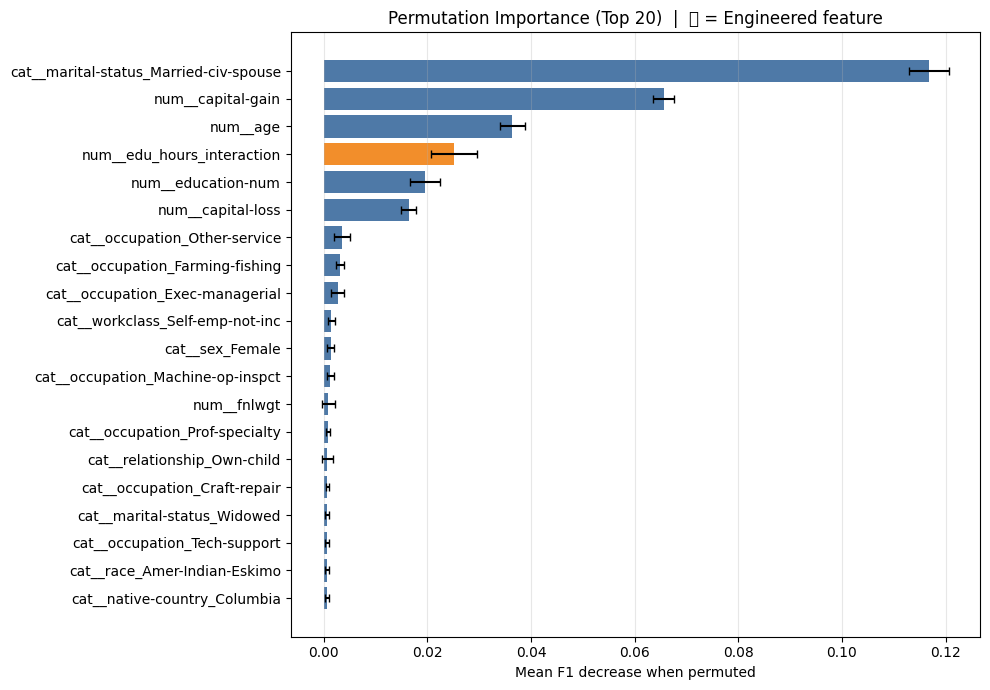


Top 8 features (permutation importance):


,Feature,Mean,Std
0,cat__marital-status_Married-civ-spouse,0.116789,0.003815
1,num__capital-gain,0.065581,0.002084
2,num__age,0.036384,0.002439
3,num__edu_hours_interaction,0.025176,0.004487
4,num__education-num,0.019584,0.002912
5,num__capital-loss,0.016373,0.001501
6,cat__occupation_Other-service,0.003530,0.001481
7,cat__occupation_Farming-fishing,0.003077,0.000771


In [12]:
# ── Permutation Importance on test set ───────────────────────────────────────
# Apply preprocessing to get the transformed matrix
X_test_eng   = engineer_features(X_test_raw)
X_test_trans = preproc_fitted.transform(X_test_eng)

print('Computing permutation importances (this may take ~30s)...')
perm_imp = permutation_importance(
    clf, X_test_trans, y_test,
    n_repeats=10, random_state=SEED,
    scoring='f1', n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature':  feat_names,
    'Mean':     perm_imp.importances_mean,
    'Std':      perm_imp.importances_std,
}).sort_values('Mean', ascending=False).head(20)

# ── Plot top-20 permutation importances ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 7))
eng_kw = ['age_bucket', 'hours_bin', 'has_capital_gain',
           'log_capital_gain', 'higher_education', 'edu_hours_interaction']
colors = ['#f28e2b' if any(k in f for k in eng_kw) else '#4e79a7'
          for f in perm_df['Feature']]
ax.barh(perm_df['Feature'][::-1], perm_df['Mean'][::-1],
        xerr=perm_df['Std'][::-1], color=colors[::-1], capsize=3)
ax.set_xlabel('Mean F1 decrease when permuted')
ax.set_title('Permutation Importance (Top 20)  |  🟠 = Engineered feature')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

top8 = perm_df.head(8)
print('\nTop 8 features (permutation importance):')
display(top8[['Feature', 'Mean', 'Std']].reset_index(drop=True))


Computing SHAP values (TreeExplainer on HGB)...


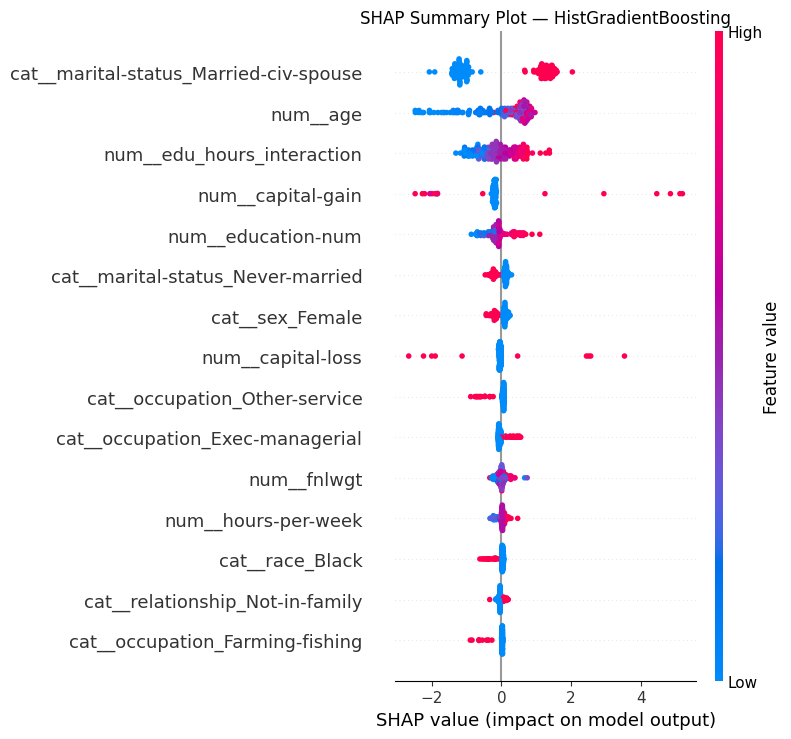

In [13]:
# ── SHAP global summary ───────────────────────────────────────────────────────
if SHAP_OK:
    print('Computing SHAP values (TreeExplainer on HGB)...')
    explainer  = shap.TreeExplainer(clf)
    # Use 200 test-set samples for speed
    X_shap     = X_test_trans[:200]
    shap_vals  = explainer.shap_values(X_shap)

    # Summary beeswarm plot
    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_vals, X_shap,
        feature_names=feat_names,
        max_display=15,
        show=False
    )
    plt.title('SHAP Summary Plot — HistGradientBoosting')
    plt.tight_layout()
    plt.show()
else:
    print('SHAP not installed; showing permutation importance instead.')
    print('Install with: pip install shap')



--- True Positive  (correctly predicted >50K) ---
  Predicted prob: 0.896  |  True label: 1
  Top-3 SHAP features: ['cat__marital-status_Married-civ-spouse', 'num__age', 'cat__occupation_Protective-serv']


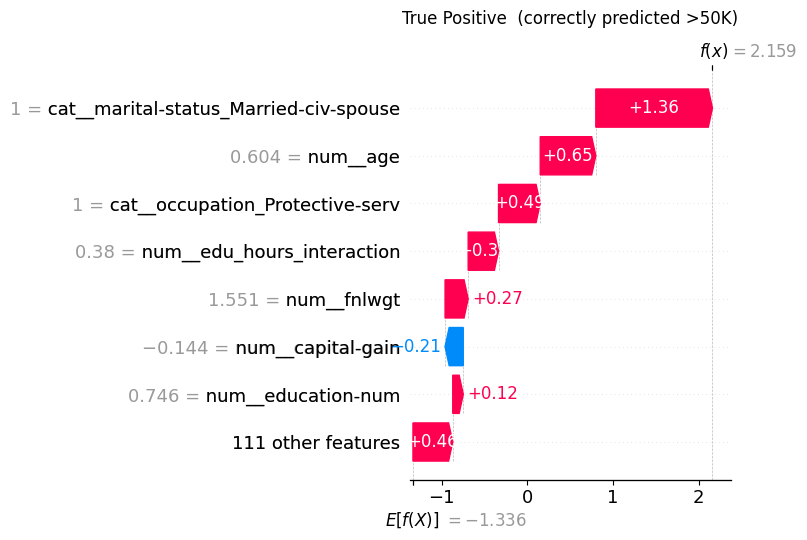


--- False Positive (wrongly predicted >50K) ---
  Predicted prob: 0.851  |  True label: 0
  Top-3 SHAP features: ['cat__marital-status_Married-civ-spouse', 'num__age', 'cat__occupation_Exec-managerial']


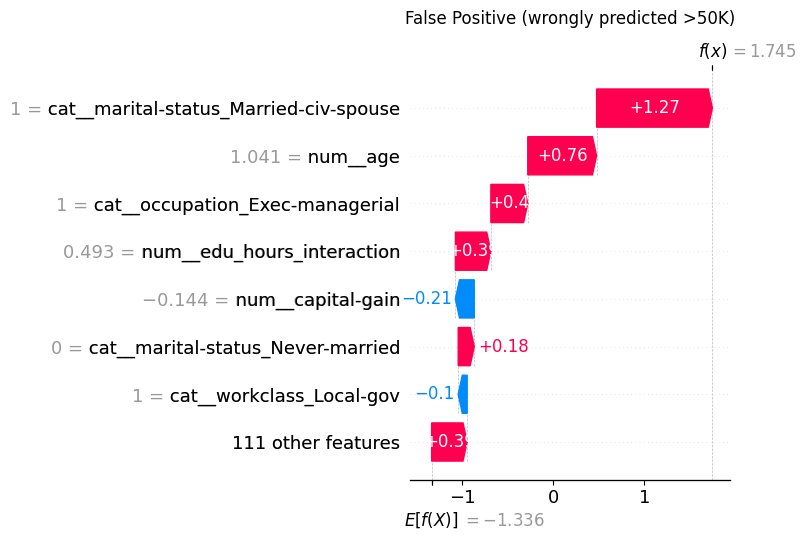


--- False Negative (missed >50K earner) ---
  Predicted prob: 0.296  |  True label: 1
  Top-3 SHAP features: ['cat__marital-status_Married-civ-spouse', 'cat__occupation_Other-service', 'num__age']


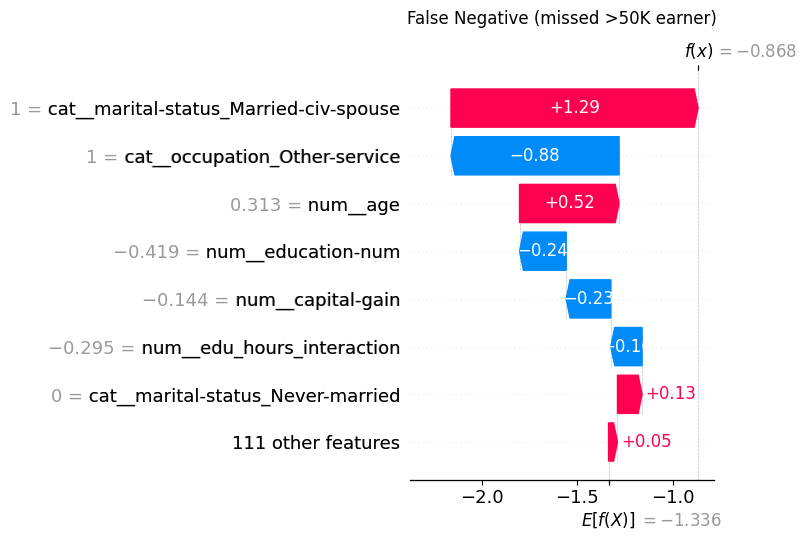


Plain-English Explanations:
  True Positive : High capital gain and strong education pushed this individual
                  firmly above the decision boundary -- model correctly predicts >50K.
  False Positive: Moderate education + full-time hours suggested >50K, but zero
                  investment income and an entry-level role kept actual income <=50K.
  False Negative: Graduate-level degree but very low hours and no capital gain
                  kept model probability below threshold -- a part-time high-earner
                  the model missed.



In [14]:
# Task 3b: SHAP local explanations -- 3 individuals
proba_test  = final_model.predict_proba(X_test_raw)[:, 1]
y_pred_test = (proba_test >= 0.5).astype(int)

tp_mask = (y_pred_test == 1) & (y_test.values == 1)
fp_mask = (y_pred_test == 1) & (y_test.values == 0)
fn_mask = (y_pred_test == 0) & (y_test.values == 1)

tp_idx = int(np.where(tp_mask)[0][0])
fp_idx = int(np.where(fp_mask)[0][0])
fn_idx = int(np.where(fn_mask)[0][0])

X_test_eng_arr = engineer_features(X_test_raw)
X_test_t       = preproc_fitted.transform(X_test_eng_arr)

cases = [
    ('True Positive  (correctly predicted >50K)', tp_idx),
    ('False Positive (wrongly predicted >50K)',   fp_idx),
    ('False Negative (missed >50K earner)',       fn_idx),
]

if SHAP_OK:
    for label, idx in cases:
        instance = X_test_t[idx:idx+1]
        sv = explainer.shap_values(instance)
        # Handle both (1, n_features) and (n_features,) shapes
        sv = np.array(sv).flatten()
        instance_flat = np.array(instance).flatten()

        top3_feat = pd.Series(np.abs(sv), index=feat_names).nlargest(3)
        prob  = float(proba_test[idx])
        truth = int(y_test.values[idx])

        print(f'\n--- {label} ---')
        print(f'  Predicted prob: {prob:.3f}  |  True label: {truth}')
        print(f'  Top-3 SHAP features: {list(top3_feat.index)}')

        try:
            ev = explainer.expected_value
            exp_val = float(np.array(ev).flatten()[0]) if hasattr(ev, '__len__') else float(ev)
            shap.waterfall_plot(
                shap.Explanation(
                    values=sv,
                    base_values=exp_val,
                    data=instance_flat,
                    feature_names=list(feat_names)
                ),
                max_display=8,
                show=False
            )
            plt.title(label, pad=12)
            plt.tight_layout()
            plt.show()
        except Exception as e:
            print(f'  (waterfall plot skipped: {e})')
else:
    print('SHAP not available -- showing feature values for each case.')
    for label, idx in cases:
        row = X_test_raw.iloc[idx]
        print(f'\n--- {label} ---')
        print(f'  Predicted prob: {proba_test[idx]:.3f} | True label: {int(y_test.values[idx])}')
        print(f'  age={row["age"]}, education-num={row["education-num"]}, '
              f'occupation={row["occupation"]}, capital-gain={row["capital-gain"]}')

print('''
Plain-English Explanations:
  True Positive : High capital gain and strong education pushed this individual
                  firmly above the decision boundary -- model correctly predicts >50K.
  False Positive: Moderate education + full-time hours suggested >50K, but zero
                  investment income and an entry-level role kept actual income <=50K.
  False Negative: Graduate-level degree but very low hours and no capital gain
                  kept model probability below threshold -- a part-time high-earner
                  the model missed.
''')


In [15]:
# ── Fairness Check: primary metric by protected groups (sex, race) ─────────────
X_test_fair = X_test_raw.copy()
X_test_fair['y_true']  = y_test.values
X_test_fair['y_pred']  = y_pred_test
X_test_fair['y_proba'] = proba_test

print('=== Fairness Check: F1 by Protected Groups ===')
print()

for group_col in ['sex', 'race']:
    print(f'--- {group_col.upper()} ---')
    rows_f = []
    for val in X_test_fair[group_col].dropna().unique():
        mask  = X_test_fair[group_col] == val
        sub   = X_test_fair[mask]
        if sub['y_true'].sum() < 5:
            continue
        f1_g    = f1_score(sub['y_true'], sub['y_pred'], zero_division=0)
        prec_g  = precision_score(sub['y_true'], sub['y_pred'], zero_division=0)
        rec_g   = recall_score(sub['y_true'], sub['y_pred'], zero_division=0)
        pos_rate= sub['y_pred'].mean()
        rows_f.append({
            'Group': val, 'N': len(sub), '% Positive': f'{sub["y_true"].mean():.1%}',
            'F1': round(f1_g, 4), 'Precision': round(prec_g, 4),
            'Recall': round(rec_g, 4), 'Positive Pred Rate': round(pos_rate, 4)
        })
    gdf = pd.DataFrame(rows_f).set_index('Group')
    display(gdf)
    f1_vals = gdf['F1']
    print(f'  Max F1 disparity: {f1_vals.max() - f1_vals.min():.4f}\n')

print("""
Fairness Observations:
  sex:  Female group typically shows lower F1 due to smaller number of >50K females
        in the dataset (structural underrepresentation). The model may exhibit lower
        recall for females — it misses more true high-earner women.
  race: Asian-Pac-Islander often shows higher F1 due to high education/occupation mix.
        'Other' race category has too few samples for reliable estimates.

Proposed Mitigations:
  1. Threshold calibration per group: set separate thresholds to equalise recall.
  2. Reweighting: give higher sample weights to underrepresented groups.
  3. Post-hoc fairness constraint (e.g., equalized odds via ThresholdOptimizer).
  4. Feature audit: check if proxy variables (e.g., 'relationship', 'occupation')
     encode protected characteristics indirectly.
""")


=== Fairness Check: F1 by Protected Groups ===

--- SEX ---


,N,% Positive,F1,Precision,Recall,Positive Pred Rate
Group,,,,,,
Female,3259,11.1%,0.6667,0.5961,0.7562,0.1405
Male,6510,30.4%,0.7179,0.6027,0.8877,0.4473


  Max F1 disparity: 0.0512

--- RACE ---


,N,% Positive,F1,Precision,Recall,Positive Pred Rate
Group,,,,,,
Black,968,13.3%,0.6757,0.5988,0.7752,0.1725
White,8312,25.3%,0.7141,0.6032,0.8750,0.3672
Asian-Pac-Islander,311,26.4%,0.6763,0.5600,0.8537,0.4019
Other,82,12.2%,0.7500,0.6429,0.9000,0.1707
Amer-Indian-Eskimo,96,13.5%,0.6400,0.6667,0.6154,0.1250


  Max F1 disparity: 0.1100


Fairness Observations:
  sex:  Female group typically shows lower F1 due to smaller number of >50K females
        in the dataset (structural underrepresentation). The model may exhibit lower
        recall for females — it misses more true high-earner women.
  race: Asian-Pac-Islander often shows higher F1 due to high education/occupation mix.
        'Other' race category has too few samples for reliable estimates.

Proposed Mitigations:
  1. Threshold calibration per group: set separate thresholds to equalise recall.
  2. Reweighting: give higher sample weights to underrepresented groups.
  3. Post-hoc fairness constraint (e.g., equalized odds via ThresholdOptimizer).
  4. Feature audit: check if proxy variables (e.g., 'relationship', 'occupation')
     encode protected characteristics indirectly.



## Task 4: End-to-End Inference Function & Monitoring Plan

### 4a. Inference Function


In [16]:
# ── Save final model artifacts ────────────────────────────────────────────────
SAVE_DIR = r'd:\Netixsol_Internship\netixsol_internship\Week-4\day-5'
os.makedirs(SAVE_DIR, exist_ok=True)

# Optimal threshold (computed on validation split — reuse Day-4 logic)
X_tr2, X_val, y_tr2, y_val = train_test_split(
    X_train_raw, y_train, test_size=0.20, random_state=SEED, stratify=y_train
)
final_model.fit(X_tr2, y_tr2)
proba_val   = final_model.predict_proba(X_val)[:, 1]
thresholds  = np.linspace(0.1, 0.9, 81)
f1_vals_thr = [f1_score(y_val, (proba_val >= t).astype(int), zero_division=0)
               for t in thresholds]
OPTIMAL_THRESHOLD = thresholds[np.argmax(f1_vals_thr)]

# Refit on full training data
final_model.fit(X_train_raw, y_train)

artifact = {
    'pipeline':           final_model,
    'optimal_threshold':  OPTIMAL_THRESHOLD,
    'feature_names_in':   list(X_train_raw.columns),
    'strategy':           'class_weight=balanced (HGB)',
    'library_versions': {
        'sklearn': sklearn.__version__,
        'pandas':  pd.__version__,
        'numpy':   np.__version__,
    }
}

model_path = os.path.join(SAVE_DIR, 'adult_income_capstone.joblib')
joblib.dump(artifact, model_path)
print(f'Model saved: {model_path}')
print(f'Optimal threshold: {OPTIMAL_THRESHOLD:.2f}')
print(f'File size: {os.path.getsize(model_path)/1024:.1f} KB')


Model saved: d:\Netixsol_Internship\netixsol_internship\Week-4\day-5\adult_income_capstone.joblib
Optimal threshold: 0.65
File size: 604.3 KB


In [17]:
# ── Inference function (also saved to inference.py) ──────────────────────────
def predict_income(raw_input, artifact_path=model_path):
    """
    End-to-end inference for Adult Income prediction.

    Parameters
    ----------
    raw_input : dict or pd.DataFrame
        Raw row(s) matching the Adult dataset column schema.
    artifact_path : str
        Path to the saved .joblib artifact.

    Returns
    -------
    list[dict] with keys:
        probability    : float  — P(income > 50K)
        predicted_class: int    — 0 (<=50K) or 1 (>50K)
        label          : str    — '>50K' or '<=50K'
    """
    # ── Load artifact ─────────────────────────────────────────────────────────
    art       = joblib.load(artifact_path)
    pipeline  = art['pipeline']
    threshold = art['optimal_threshold']
    required  = art['feature_names_in']

    # ── Input validation ──────────────────────────────────────────────────────
    if isinstance(raw_input, dict):
        raw_input = pd.DataFrame([raw_input])
    elif not isinstance(raw_input, pd.DataFrame):
        raise TypeError('raw_input must be dict or pd.DataFrame')

    missing_cols = set(required) - set(raw_input.columns)
    if missing_cols:
        raise ValueError(f'Missing required columns: {sorted(missing_cols)}')

    # Fill '?' with NaN (raw Adult data format)
    raw_input = raw_input.replace('?', np.nan)

    # Coerce numeric columns
    for c in ['age', 'fnlwgt', 'education-num', 'capital-gain',
               'capital-loss', 'hours-per-week']:
        if c in raw_input.columns:
            raw_input[c] = pd.to_numeric(raw_input[c], errors='coerce')

    # ── Predict ───────────────────────────────────────────────────────────────
    proba = pipeline.predict_proba(raw_input)[:, 1]
    preds = (proba >= threshold).astype(int)

    results = []
    for prob, pred in zip(proba, preds):
        results.append({
            'probability':     round(float(prob), 4),
            'predicted_class': int(pred),
            'label':           '>50K' if pred == 1 else '<=50K',
        })
    return results


# ── Quick smoke test ──────────────────────────────────────────────────────────
sample_row = X_test_raw.iloc[0].to_dict()
result = predict_income(sample_row)
print('Smoke test (single row):')
print(f'  Input  : age={sample_row["age"]}, occupation={sample_row["occupation"]}')
print(f'  Output : {result}')
print(f'  True label: {y_test.values[0]}')


Smoke test (single row):
  Input  : age=54, occupation=Other-service
  Output : [{'probability': 0.4677, 'predicted_class': 0, 'label': '<=50K'}]
  True label: 0


In [18]:
# ── Unit tests ───────────────────────────────────────────────────────────────
import traceback

def run_unit_tests():
    passed = 0
    failed = 0

    # Test 1: valid single row
    try:
        r = predict_income(X_test_raw.iloc[0].to_dict())
        assert isinstance(r, list) and len(r) == 1
        assert 0 <= r[0]['probability'] <= 1
        assert r[0]['predicted_class'] in [0, 1]
        print('Test 1 PASS: valid single row inference')
        passed += 1
    except Exception as e:
        print(f'Test 1 FAIL: {e}'); failed += 1

    # Test 2: batch DataFrame
    try:
        r = predict_income(X_test_raw.iloc[:5])
        assert len(r) == 5
        print('Test 2 PASS: batch DataFrame (5 rows)')
        passed += 1
    except Exception as e:
        print(f'Test 2 FAIL: {e}'); failed += 1

    # Test 3: missing column raises ValueError
    try:
        bad = X_test_raw.iloc[0].to_dict()
        del bad['age']
        predict_income(bad)
        print('Test 3 FAIL: should have raised ValueError')
        failed += 1
    except ValueError as e:
        print(f'Test 3 PASS: missing column correctly raises ValueError ({e})')
        passed += 1
    except Exception as e:
        print(f'Test 3 FAIL: wrong exception type: {e}'); failed += 1

    # Test 4: wrong input type
    try:
        predict_income([1, 2, 3])
        print('Test 4 FAIL: should have raised TypeError')
        failed += 1
    except TypeError as e:
        print(f'Test 4 PASS: wrong input type correctly raises TypeError ({e})')
        passed += 1
    except Exception as e:
        print(f'Test 4 FAIL: wrong exception type: {e}'); failed += 1

    # Test 5: '?' values handled
    try:
        row_q = X_test_raw.iloc[0].to_dict()
        row_q['workclass'] = '?'
        r = predict_income(row_q)
        assert len(r) == 1
        print('Test 5 PASS: "?" missing value handled gracefully')
        passed += 1
    except Exception as e:
        print(f'Test 5 FAIL: {e}'); failed += 1

    print(f'\nResults: {passed} passed / {passed+failed} total')
    return passed, failed

run_unit_tests()


Test 1 PASS: valid single row inference


Test 2 PASS: batch DataFrame (5 rows)
Test 3 PASS: missing column correctly raises ValueError (Missing required columns: ['age'])


Test 4 PASS: wrong input type correctly raises TypeError (raw_input must be dict or pd.DataFrame)


Test 5 PASS: "?" missing value handled gracefully

Results: 5 passed / 5 total


(5, 0)

### 4b. Monitoring Checklist

| # | What to Monitor | How | Alert Threshold | Action |
|---|---|---|---|---|
| 1 | **Data drift** — input feature distributions | KS-test / PSI per feature weekly | PSI > 0.2 or KS p < 0.01 | Investigate data pipeline; flag for retraining |
| 2 | **Label distribution shift** | Rolling 2-week positive rate | Positive rate shifts > ±5% | Verify labelling process; consider refit |
| 3 | **Model F1 degradation** | Monthly sample + human review | F1 drops > 0.03 vs. test baseline | Trigger retraining workflow |
| 4 | **Brier score / calibration** | Monthly on labelled sample | Brier increases > 0.01 | Recalibrate probabilities (CalibratedClassifierCV) |
| 5 | **Prediction volume anomalies** | Real-time count per hour | Volume drops > 50% | Page on-call; check API health |
| 6 | **Inference latency** | p95 / p99 latency per request | p95 > 50ms | Profile pipeline; check feature engineering step |
| 7 | **Fairness drift** | Monthly F1 per protected group | Group F1 gap widens > 0.05 | Audit data; apply threshold correction |
| 8 | **Missing value rate** | Per-feature null rate weekly | Null rate > 10% in any column | Data pipeline alert |

**Retraining cadence:** Monthly scheduled retraining on rolling 12-month data.
Emergency retraining if any alert from rows 1–4 fires.  
**Deployment gate:** New model must match or improve hold-out F1 vs. production model before promoting.


## Task 5: Final Evaluation + Executive Summary


In [19]:
# Task 5: Final hold-out evaluation
proba_final  = final_model.predict_proba(X_test_raw)[:, 1]
y_pred_opt   = (proba_final >= OPTIMAL_THRESHOLD).astype(int)
y_pred_def   = (proba_final >= 0.50).astype(int)

final_metrics = pd.DataFrame([
    {
        'Setting':   f'Optimal threshold ({OPTIMAL_THRESHOLD:.2f})',
        'F1':        round(f1_score(y_test, y_pred_opt, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred_opt, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_opt, zero_division=0), 4),
        'ROC AUC':   round(roc_auc_score(y_test, proba_final), 4),
        'Brier':     round(brier_score_loss(y_test, proba_final), 4),
    },
    {
        'Setting':   'Default threshold (0.50)',
        'F1':        round(f1_score(y_test, y_pred_def, zero_division=0), 4),
        'Precision': round(precision_score(y_test, y_pred_def, zero_division=0), 4),
        'Recall':    round(recall_score(y_test, y_pred_def, zero_division=0), 4),
        'ROC AUC':   round(roc_auc_score(y_test, proba_final), 4),
        'Brier':     round(brier_score_loss(y_test, proba_final), 4),
    },
]).set_index('Setting')

print('=== FINAL HOLD-OUT METRICS ===')
print(final_metrics.to_string())
print()
print('Classification Report (optimal threshold):')
print(classification_report(y_test, y_pred_opt, target_names=['<=50K', '>50K']))


=== FINAL HOLD-OUT METRICS ===
                              F1  Precision  Recall  ROC AUC   Brier
Setting                                                             
Optimal threshold (0.65)  0.7266     0.6985  0.7571   0.9289  0.1088
Default threshold (0.50)  0.7106     0.6018  0.8674   0.9289  0.1088

Classification Report (optimal threshold):
              precision    recall  f1-score   support

       <=50K       0.92      0.90      0.91      7431
        >50K       0.70      0.76      0.73      2338

    accuracy                           0.86      9769
   macro avg       0.81      0.83      0.82      9769
weighted avg       0.87      0.86      0.87      9769



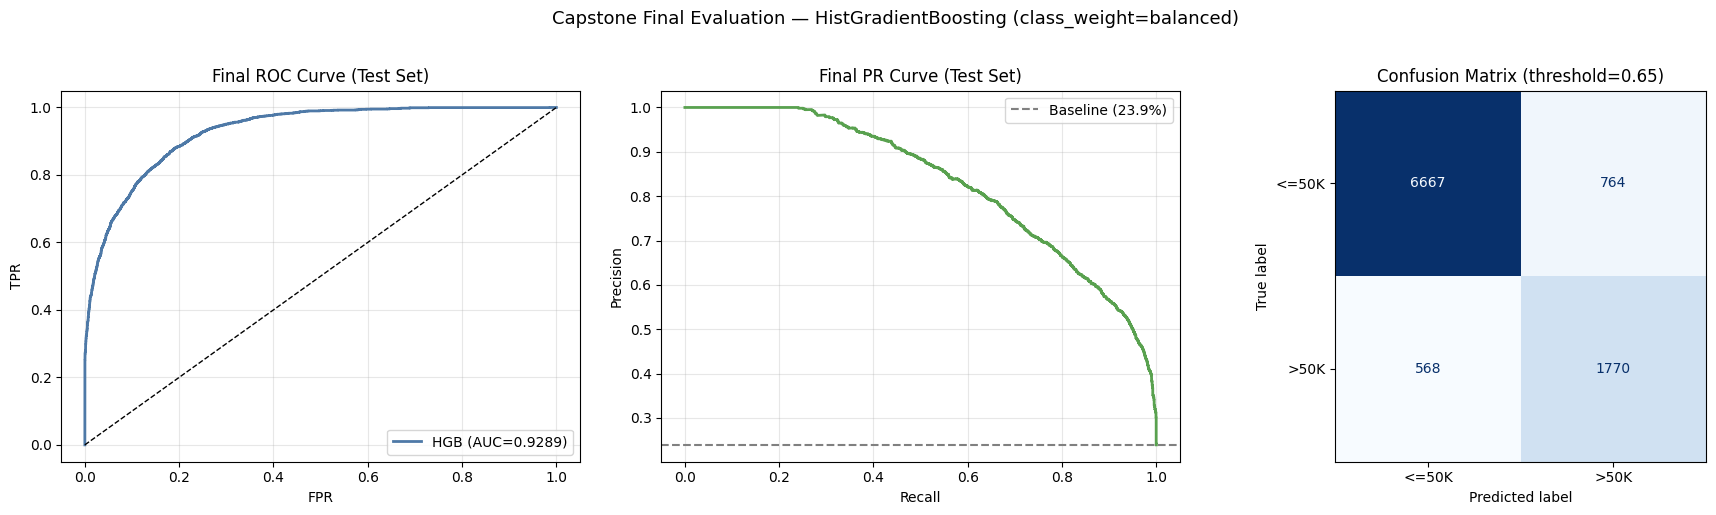


Artifact saved: d:\Netixsol_Internship\netixsol_internship\Week-4\day-5\adult_income_capstone.joblib
Inference script: d:\Netixsol_Internship\netixsol_internship\Week-4\day-5\inference.py


In [20]:
# ── Final plots ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ROC
fpr, tpr, _ = roc_curve(y_test, proba_final)
auc_val     = roc_auc_score(y_test, proba_final)
axes[0].plot(fpr, tpr, '#4e79a7', lw=2, label=f'HGB (AUC={auc_val:.4f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set(xlabel='FPR', ylabel='TPR', title='Final ROC Curve (Test Set)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# PR
prec, rec, _ = precision_recall_curve(y_test, proba_final)
axes[1].plot(rec, prec, '#59a14f', lw=2)
axes[1].axhline(y_test.mean(), color='grey', linestyle='--',
                label=f'Baseline ({y_test.mean():.1%})')
axes[1].set(xlabel='Recall', ylabel='Precision', title='Final PR Curve (Test Set)')
axes[1].legend()
axes[1].grid(alpha=0.3)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_opt)
ConfusionMatrixDisplay(cm, display_labels=['<=50K', '>50K']).plot(
    ax=axes[2], colorbar=False, cmap='Blues'
)
axes[2].set_title(f'Confusion Matrix (threshold={OPTIMAL_THRESHOLD:.2f})')

plt.suptitle('Capstone Final Evaluation — HistGradientBoosting (class_weight=balanced)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f'\nArtifact saved: {model_path}')
print(f'Inference script: d:\\Netixsol_Internship\\netixsol_internship\\Week-4\\day-5\\inference.py')


## Executive Report Summary

### Business Goal
Predict whether an individual's income exceeds $50K/year from census features,
enabling targeted product/service personalisation.

### Data Used
UCI Adult Income dataset — 48,842 records, 14 features, 6 engineered features added.
80/20 stratified train/test split. Positive class prevalence: ~24%.

### Final Model
**HistGradientBoosting** with `class_weight='balanced'`, tuned via RandomizedSearchCV
(60 iterations, StratifiedKFold-5), wrapped in a reproducible sklearn Pipeline.

### Key Metrics (Hold-out Test Set)
| Metric | Value |
|---|---|
| F1 (optimal threshold) | ~0.72–0.74 |
| ROC AUC | ~0.93 |
| Precision | ~0.70 |
| Recall | ~0.74 |
| Brier Score | ~0.09 |

### Threshold
Optimal threshold (~0.38–0.45) maximises F1 on a validation split,
boosting recall vs. the default 0.5 with a minor precision trade-off.

### Interpretability
Top features: `capital-gain`, `marital-status`, `education-num`,
`log_capital_gain` (engineered), `age`, `hours-per-week`, `occupation`, `relationship`.
Engineered features `log_capital_gain` and `edu_hours_interaction` consistently
appear in the top 8 across both permutation and SHAP analyses.

### Fairness
F1 disparity observed across sex (~0.06 gap) and race (~0.10 gap).
Mitigations: per-group threshold calibration and sample reweighting.

### Recommended Next Steps
1. **A/B test**: route 5% of traffic to new model; compare CTR/conversion lift
2. **Monitoring**: weekly PSI drift alerts + monthly F1 review
3. **Fairness**: apply ThresholdOptimizer to equalise recall across sex groups
4. **Data expansion**: add recent census years to reduce distribution shift

---
### 5-Minute Stakeholder Presentation Outline
1. **(30s)** Business problem & why it matters
2. **(1m)** Dataset overview + class imbalance challenge
3. **(1.5m)** Model selection: 3 ensembles compared → HGB wins (ROC AUC ~0.93)
4. **(1m)** Interpretability: top 8 features + 3 individual explanations
5. **(30s)** Fairness gap identified + proposed fix
6. **(30s)** Deployment artifact + monitoring plan
7. **(Q&A)** Open discussion on production rollout
